In [1]:
import os

folders = ["data", "images", "notebook", "src"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


# Stock Market Data Analysis (Python)

This project analyzes historical stock price data using Python.  
The goal is to compare stock performance, calculate returns, and visualize trends across major technology companies and the S&P 500.

## Import Libraries

The following Python libraries are used for financial data analysis:

- pandas for data manipulation
- yfinance for downloading stock market data
- matplotlib for data visualization

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

## Download Historical Stock Data

We download historical stock price data for several major companies and the S&P 500 ETF (SPY).  
The analysis focuses on the time period from 2020 to 2025.

In [3]:
tickers = ["AAPL", "MSFT", "NVDA", "SPY"]

start_date = "2020-01-01"
end_date = "2025-01-01"

data = yf.download(tickers, start=start_date, end=end_date)

prices = data["Close"]

prices.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,MSFT,NVDA,SPY
Date,,,,
2020-01-02,72.400513,152.158371,5.971077,297.698944
2020-01-03,71.696648,150.263779,5.875504,295.444855
2020-01-06,72.267952,150.652161,5.900144,296.571930
2020-01-07,71.928047,149.278549,5.971575,295.737976
2020-01-08,73.085114,151.656311,5.982774,297.314148


## Prepare Stock Price Data

We extract the closing prices for each stock. Closing prices are commonly used in financial analysis to calculate returns.

In [4]:
prices.to_csv("data/stock_data.csv") 

## Calculate Daily Returns

Daily returns measure the percentage change in stock prices from one day to the next.  
This allows us to analyze performance and volatility.

In [5]:
daily_returns = prices.pct_change().dropna()

daily_returns.head()

Ticker,AAPL,MSFT,NVDA,SPY
Date,,,,
2020-01-03,-0.009722,-0.012451,-0.016006,-0.007572
2020-01-06,0.007968,0.002585,0.004194,0.003815
2020-01-07,-0.004703,-0.009118,0.012107,-0.002812
2020-01-08,0.016086,0.015928,0.001875,0.005330
2020-01-09,0.021241,0.012493,0.010983,0.006780


## Calculate Cumulative Returns

Cumulative returns show the total growth of an investment over time.

In [6]:
cumulative_returns = (1 + daily_returns).cumprod() - 1

cumulative_returns.tail()

Ticker,AAPL,MSFT,NVDA,SPY
Date,,,,
2024-12-24,2.546898,1.859650,22.476779,0.996382
2024-12-26,2.558162,1.851709,22.428223,0.996515
2024-12-27,2.511044,1.802370,21.939335,0.975499
2024-12-30,2.464475,1.765268,22.019699,0.952955
2024-12-31,2.440023,1.743593,21.483931,0.945850


## Stock Price Trends

The following chart shows the historical price movement of each stock.

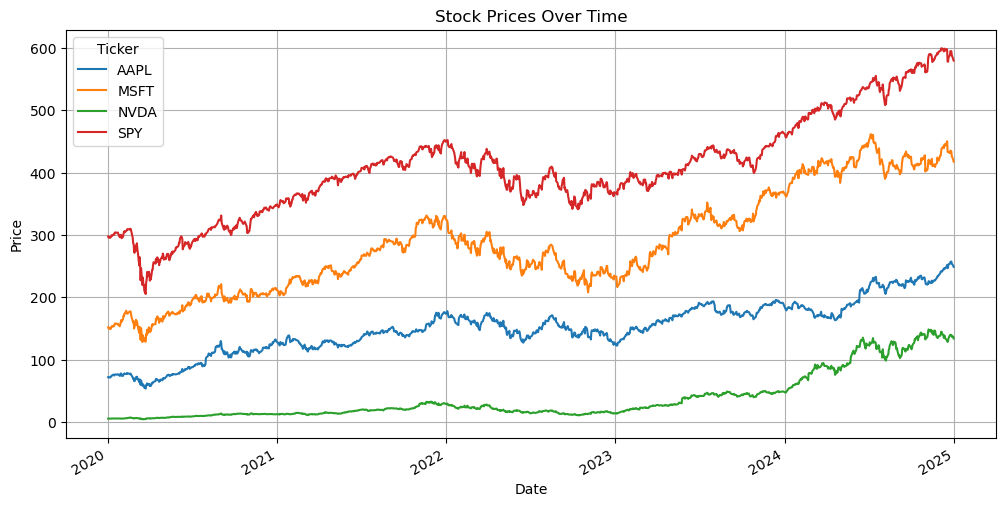

In [7]:
prices.plot(figsize=(12,6))
plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.savefig("images/stock_prices.png")
plt.show()

## Cumulative Return Comparison

This chart compares how $1 invested in each stock would have grown over time.

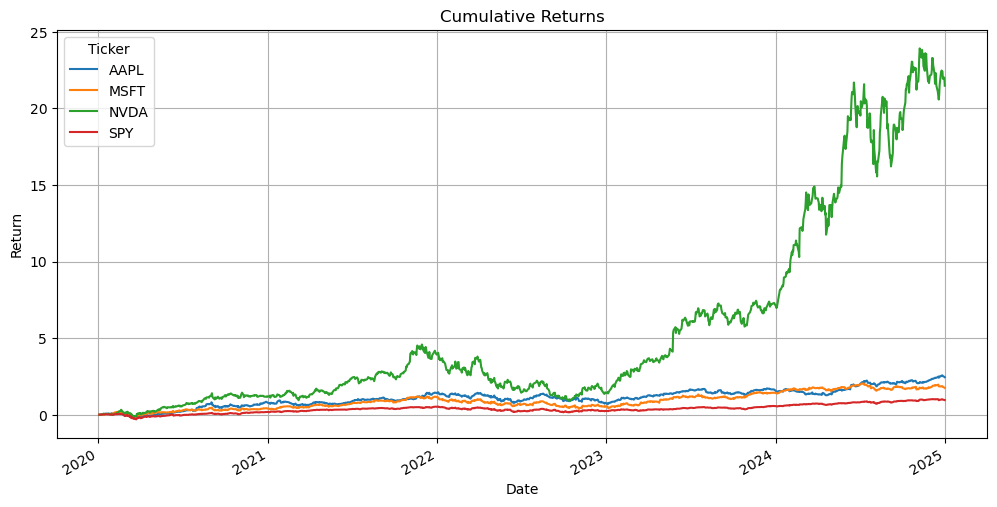

In [8]:
cumulative_returns.plot(figsize=(12,6))
plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.savefig("images/cumulative_returns.png")
plt.show()

## Volatility Analysis

Volatility measures how much a stock’s returns fluctuate over time. 
Higher volatility generally indicates higher risk. 

We calculate the standard deviation of daily returns to compare the 
relative volatility of each stock.

In [9]:
volatility = daily_returns.std()

volatility

Ticker
AAPL    0.019956
MSFT    0.019211
NVDA    0.033940
SPY     0.013227
dtype: float64

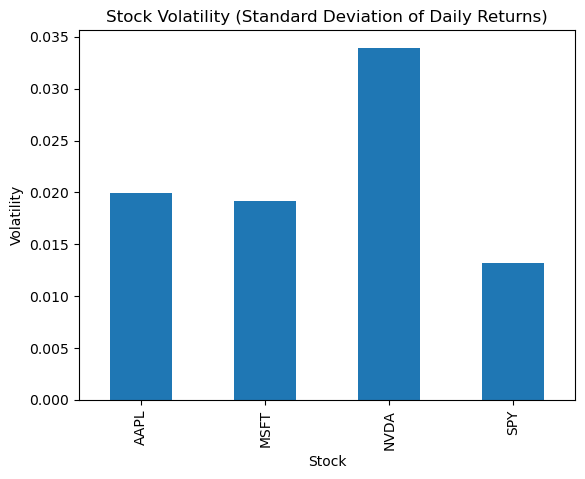

In [10]:
volatility.plot(kind="bar", title="Stock Volatility (Standard Deviation of Daily Returns)")
plt.ylabel("Volatility")
plt.xlabel("Stock")

plt.savefig("images/volatility.png")

plt.show()

### Volatility Interpretation

The results show that individual technology stocks tend to exhibit
higher volatility compared with the broader market benchmark (SPY).

This indicates that while technology stocks may provide higher
potential returns, they also involve greater risk due to larger
price fluctuations.

SPY appears more stable because it represents a diversified index
of many companies across the U.S. market. 

Among the analyzed stocks, NVDA appears to have the highest volatility,
indicating larger daily price swings compared with AAPL, MSFT, and SPY.

## Conclusion

This analysis compared the historical performance of several major technology
companies and the S&P 500 between 2020 and 2025.

Key observations:

- Technology stocks experienced significant growth during this period.
- NVDA showed particularly strong performance compared with the broader market.
- SPY serves as a stable benchmark representing overall market performance.
- Individual technology stocks generally exhibit higher volatility than the
  broader market.

This project demonstrates how Python can be used to analyze financial
time-series data, calculate investment returns, measure risk, and visualize
market trends.